Нужно посмотреть датасет на предмет 1) сколько блюд состоят из 1 ингридиента - в таком случае точно будет понятна калорийность некоторых 
ингридиентов на 100г 2) насколько однородны ингридиенты блюд в тесте и трейне

In [7]:
import pandas as pd
from Config import Config  # импортируем класс Config

# DATA_CSV = "data/dish.csv"

# === Загружаем данные ===
df = pd.read_csv(Config.DATA_CSV)



df_train = df[df["split"] == "train"].reset_index(drop=True)

# === TRAIN ингредиенты ===
train_ingredients = set()
for ingr_str in df_train["ingredients"]:
    train_ingredients.update(ingr_str.split(";"))

print("="*60)
print(" ОБЩАЯ СТАТИСТИКА TRAIN")
print("="*60)

print(f"Всего блюд (train): {len(df_train)}")
print(f"Всего уникальных ингредиентов (train): {len(train_ingredients)}")

# --- Блюда с 1 ингредиентом ---
single_ingr_train = df_train[df_train["ingredients"].str.count(";") == 0]
print(f"Блюд с 1 ингредиентом (train): {len(single_ingr_train)}")


 ОБЩАЯ СТАТИСТИКА TRAIN
Всего блюд (train): 2755
Всего уникальных ингредиентов (train): 198
Блюд с 1 ингредиентом (train): 749


In [8]:
import pandas as pd
from Config import Config  # импортируем класс Config

# DATA_CSV = "data/dish.csv"

# === Загружаем данные ===
df = pd.read_csv(Config.DATA_CSV)

df_train = df[df["split"] == "train"].reset_index(drop=True)
df_test  = df[df["split"] == "test"].reset_index(drop=True)

# === TRAIN ингредиенты ===
train_ingredients = set()
for ingr_str in df_train["ingredients"]:
    train_ingredients.update(ingr_str.split(";"))

# === TEST ингредиенты ===
test_ingredients = set()
for ingr_str in df_test["ingredients"]:
    test_ingredients.update(ingr_str.split(";"))

print("="*60)
print(" ОБЩАЯ СТАТИСТИКА TEST")
print("="*60)

print(f"Всего блюд (test): {len(df_test)}")
print(f"Всего уникальных ингредиентов (test): {len(test_ingredients)}")

# --- Блюда с 1 ингредиентом в test ---
single_ingr_test = df_test[df_test["ingredients"].str.count(";") == 0]
print(f"Блюд с 1 ингредиентом (test): {len(single_ingr_test)}")


 ОБЩАЯ СТАТИСТИКА TEST
Всего блюд (test): 507
Всего уникальных ингредиентов (test): 159
Блюд с 1 ингредиентом (test): 161


In [9]:
# === Ингредиенты в test, которых нет в train ===
test_only_ingredients = test_ingredients - train_ingredients

print("\n" + "="*60)
print("ИНГРЕДИЕНТЫ, КОТОРЫХ НЕТ В TRAIN")
print("="*60)

print(f"Всего уникальных ингредиентов в test, отсутствующих в train: {len(test_only_ingredients)}\n")

for ingr in sorted(test_only_ingredients):
    print(f" {ingr}")



ИНГРЕДИЕНТЫ, КОТОРЫХ НЕТ В TRAIN
Всего уникальных ингредиентов в test, отсутствующих в train: 2

 ingr_0000000019
 ingr_0000000141


In [10]:
common_ingredients = train_ingredients & test_ingredients

print("\n" + "="*60)
print(" ПОКРЫТИЕ TEST ИНГРЕДИЕНТОВ TRAIN'ом")
print("="*60)

print(f"Ингредиентов в train: {len(train_ingredients)}")
print(f"Ингредиентов в test: {len(test_ingredients)}")
print(f"Общих ингредиентов: {len(common_ingredients)}")

coverage = len(common_ingredients) / len(test_ingredients) * 100 if test_ingredients else 0
print(f"Покрытие test ингредиентов train'ом: {coverage:.2f}%")



 ПОКРЫТИЕ TEST ИНГРЕДИЕНТОВ TRAIN'ом
Ингредиентов в train: 198
Ингредиентов в test: 159
Общих ингредиентов: 157
Покрытие test ингредиентов train'ом: 98.74%


ВЫВОД: Видно что ингридинеты в тесте и трейне примерно одинаковые и то что калорийность чуть менее половины ингридиентов нам точно известна

Сейчас нужно вывести на печать данные чтобы посмотреть распределение и прочие параметры

In [11]:
# !pip install pandas albumentations timm transformers pillow
import pandas as pd

# Загружаем CSV
dish_df = pd.read_csv(Config.DATA_CSV)
ingr_df = pd.read_csv(Config.INGR_CSV)

# Словарь: id -> название ингредиента
ingr_map = dict(zip(
    ingr_df["id"].astype(str).str.zfill(10),
    ingr_df["ingr"]
))

def ingredients_to_text(ingr_string):
    ids = ingr_string.split(";")
    names = []
    for ingr_id in ids:
        num_id = ingr_id.replace("ingr_", "")
        if num_id in ingr_map:
            names.append(ingr_map[num_id])
    return ", ".join(names)

# Формируем текст
dish_df["text"] = dish_df["ingredients"].apply(ingredients_to_text)

# Пути к изображениям
dish_df["image_path"] = dish_df["dish_id"].apply(
    lambda x: f"{x}/rgb.png"
)

# Label = калории (REGRESSION!)
dish_df["label"] = dish_df["total_calories"]

# Train / test
train_df = dish_df[dish_df["split"] == "train"].reset_index(drop=True)
test_df  = dish_df[dish_df["split"] == "test"].reset_index(drop=True)


Визуализация данных (EDA)

Распределение калорий (target)

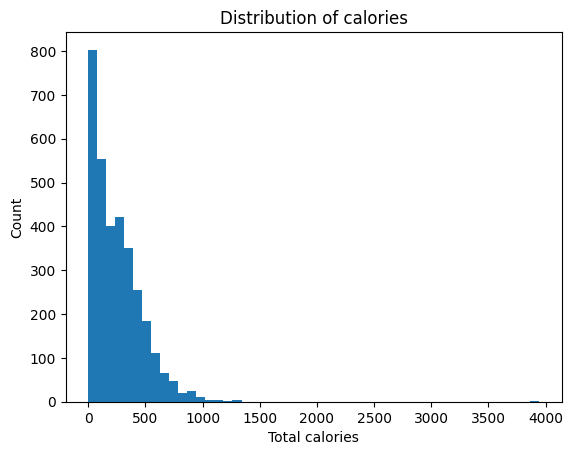

In [12]:
# !pip install matplotlib
import matplotlib.pyplot as plt

plt.figure()
plt.hist(dish_df["total_calories"], bins=50)
plt.xlabel("Total calories")
plt.ylabel("Count")
plt.title("Distribution of calories")
plt.show()



Распределение массы блюд

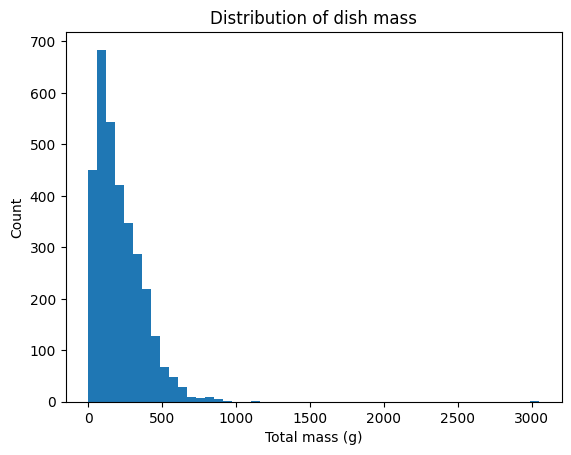

In [13]:
plt.figure()
plt.hist(dish_df["total_mass"], bins=50)
plt.xlabel("Total mass (g)")
plt.ylabel("Count")
plt.title("Distribution of dish mass")
plt.show()


In [14]:
mean_mass = dish_df["total_mass"].mean()
print(f"Average dish mass: {mean_mass:.1f} g")

Average dish mass: 215.0 g


Связь массы и калорий

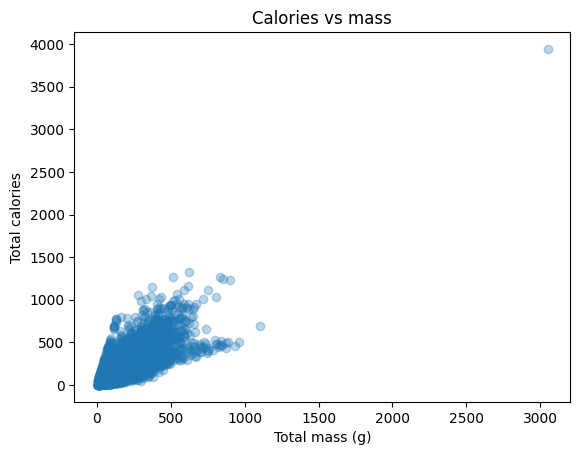

In [15]:
plt.figure()
plt.scatter(
    dish_df["total_mass"],
    dish_df["total_calories"],
    alpha=0.3
)
plt.xlabel("Total mass (g)")
plt.ylabel("Total calories")
plt.title("Calories vs mass")
plt.show()


Количество ингредиентов в блюде

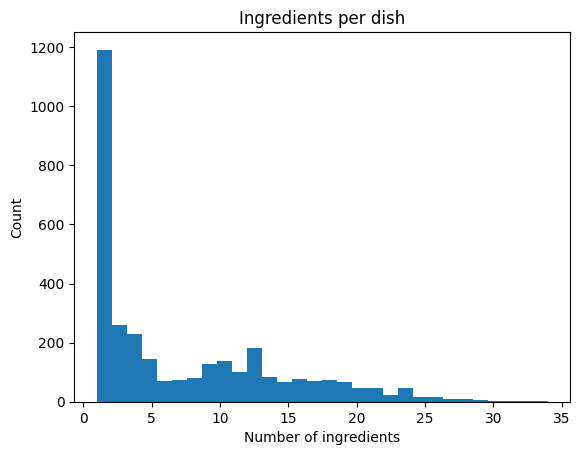

In [16]:
dish_df["num_ingredients"] = dish_df["ingredients"].apply(
    lambda x: len(x.split(";"))
)

plt.figure()
plt.hist(dish_df["num_ingredients"], bins=30)
plt.xlabel("Number of ingredients")
plt.ylabel("Count")
plt.title("Ingredients per dish")
plt.show()


ВЫВОД: калорийность зависит от массы, большая часть блюд имеет множество ингридиентов. Выбросы есть, что подтверждает необходимость нормальлизации

end